# Stock price direction prediction

## Overview

This notebook addresses the **binary classification** problem of predicting 
whether the next trading day's adjusted closing price will be higher than 
today's (`target_direction = 1`) or not (`target_direction = 0`).

The modeling pipeline consists of the following steps:
1. **Removal of features used in target construction**
2. **Train/test split** — chronological 80/20 split to preserve the 
   temporal structure of the data
3. **Feature relevance analysis** — computed exclusively on the training
   set to prevent data leakage, using Mann-Whitney U test
4. **Multicollinearity analysis** -performed using the Variance Inflation Factor (VIF).
This step was primarily motivated by the inclusion of Logistic Regression, whose coefficient estimates can become unstable when highly correlated predictors are present.
5. **Preprocessing** — missing value imputation, one-hot encoding and feature scaling 
   where required, applied within a pipeline to prevent leakage
6. **Model training** — Logistic Regression as an interpretable baseline 
   and XGBoost as the primary model
7. **Ablation study** — evaluating the incremental contribution of 
   sentiment features by comparing four feature configurations: 
   no sentiment, news only, Reddit only, and both

## 1. Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    roc_curve, auc
)
from xgboost import XGBClassifier

company_colors = {"NVDA": "#4DB6AC", "AMD": "#BA68C8", "INTC": "#5C9BD5"}
sns.set_theme(style="ticks", font_scale=1.1)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

META_COLS   = ['date']
TARGET_COL  = 'target_direction'
DROP_COLS   = META_COLS + [
                TARGET_COL, 
                'target_volatility_10d',
            ] 

SENTIMENT_COLS = [
    'reddit_sentiment',
    'news_sentiment'
]

ACTIVITY_COLS = [
    'reddit_post_count',
    'reddit_comment_count', 
    'news_count'
]

SOCIAL_NEWS_COLS = SENTIMENT_COLS + ACTIVITY_COLS

df = pd.read_csv('datasets/final/initial_processed_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['company', 'date']).reset_index(drop=True)


print(f'Shape   : {df.shape}')
print(f'Period  : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Companies: {df["company"].unique().tolist()}')

Shape   : (7413, 69)
Period  : 2016-05-31 to 2026-03-27
Companies: ['AMD', 'INTC', 'NVDA']


*Special attention is given to the following **social media and news features**:*
 - `reddit_sentiment`, `news_sentiment` — *sentiment scores derived from BERT inference*
 - `reddit_post_count`, `reddit_comment_count` — *measures of Reddit activity and engagement*
 - `news_count` — *measure of media attention intensity*

## 2. Removal of features used in target construction

`adj_close` is removed because it participates in the construction of prediction target.

`target_direction` is defined as:

$$\text{target\_direction} = \mathbb{1}\left[\text{adj\_close}_{t+1} > \text{adj\_close}_t\right]$$

*In addition, `close` is highly correlated with `adj_close` and contains nearly identical price information. Retaining either variable could allow the model to exploit information used in target construction rather than learning relationships from the remaining predictors, thereby introducing target leakage.*


In [73]:
cols_to_drop = ['adj_close', 'close']

print(f'Dropping {len(cols_to_drop)} columns: {cols_to_drop}')

df = df.drop(columns=cols_to_drop)

print(f'Shape after dropping: {df.shape}')

Dropping 2 columns: ['adj_close', 'close']
Shape after dropping: (7413, 67)


## 3. Dataset split

Since the dataset represents a financial time series, a random split 
would introduce data leakage by allowing the model to train on future 
observations and predict past ones. A chronological 80/20 split is 
therefore applied, where the first 80% of trading days form the 
training set and the remaining 20% form the test set.

In [74]:
df = df.sort_values('date').reset_index(drop=True)

split_date = df["date"].quantile(1 - TEST_SIZE)

train_df = df[df["date"] <= split_date].copy()
test_df  = df[df["date"] > split_date].copy()

print(f'Train period : {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'Test period  : {test_df["date"].min().date()} to {test_df["date"].max().date()}')
print(f'Train size   : {len(train_df)} rows ({100*(1-TEST_SIZE):.0f}%)')
print(f'Test size    : {len(test_df)} rows ({100*TEST_SIZE:.0f}%)')

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET_COL]

X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df[TARGET_COL]

print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'\nTarget distribution (train):')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nTarget distribution (test):')
print(y_test.value_counts(normalize=True).round(3))

Train period : 2016-05-31 to 2024-04-08
Test period  : 2024-04-09 to 2026-03-27
Train size   : 5931 rows (80%)
Test size    : 1482 rows (20%)

X_train shape : (5931, 63)
X_test shape  : (1482, 63)

Target distribution (train):
target_direction
1   1
0   0
Name: proportion, dtype: float64

Target distribution (test):
target_direction
1   1
0   0
Name: proportion, dtype: float64


## 4. Feature relevance analysis

*Feature relevance analysis was performed exclusively on the training set to avoid information leakage from the test data.*

Since the target variable is binary and the predictor variables do not satisfy the assumptions required by parametric tests, a non-parametric statistical approach was employed. The Mann–Whitney U test was used to assess whether the distribution of each predictor differs significantly between the two target classes.

In [55]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

*We have all numeric feature except Company. Latter in preprocessing step we will do one-hot encoding of this variable so it can be used in models that requires numeric inputs.*

### 4.1 Mann–Whitney U Test

The Mann–Whitney U test is a non-parametric statistical test used to determine whether two independent samples originate from the same distribution.

For each predictor, the Mann–Whitney U test was used to compare feature values between the two target classes (`target_direction = 0` and `target_direction = 1`).

Alongside the U statistic and p-value, the Rank-Biserial Correlation (RBC) was computed as a measure of effect size, indicating the magnitude of the difference between classes.

The Rank-Biserial Correlation (RBC) was computed as:

$$
r_{rb} = 1 - \frac{2U}{n_1 n_2}
$$

where $U$ denotes the Mann–Whitney U statistic and $n_1$ and $n_2$ represent the sizes of the two groups.

Since the Mann–Whitney U test evaluates each predictor independently, it provides insight into the individual discriminatory power of each feature.

In [56]:
mw_results = []

for feature in numeric_cols:
    # Missing values were handled on a feature-by-feature basis. 
    # For each Mann–Whitney U test, observations with missing values
    #  in the corresponding predictor were excluded from that specific analysis only,
    #  while remaining available for analyses of other predictors.
    group_0 = X_train.loc[y_train == 0, feature].dropna()
    group_1 = X_train.loc[y_train == 1, feature].dropna()

    if len(group_0) == 0 or len(group_1) == 0:
        continue

    u_stat, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative='two-sided'
    )

    n0 = len(group_0)
    n1 = len(group_1)

    rank_biserial = (2 * u_stat) / (n0 * n1) - 1

    mw_results.append({
        'feature': feature,
        'u_statistic': u_stat,
        'p_value': p_value,
        'rank_biserial': rank_biserial,
        'abs_rank_biserial': abs(rank_biserial)
    })

mw_df = (
    pd.DataFrame(mw_results)
    .sort_values('abs_rank_biserial', ascending=False)
    .reset_index(drop=True)
)

mw_df['mw_rank'] = range(1, len(mw_df) + 1)

print(mw_df.to_string(index=False))

             feature  u_statistic  p_value  rank_biserial  abs_rank_biserial  mw_rank
              std_20      4612638        0              0                  0        1
reddit_comment_count      2621376        0              0                  0        2
              wma_10      4603757        0              0                  0        3
            bb_upper      4601070        0              0                  0        4
              sma_10      4600736        0              0                  0        5
                 low      4598794        0              0                  0        6
                high      4598332        0              0                  0        7
                open      4597782        0              0                  0        8
              sma_20      4592718        0              0                  0        9
           bb_middle      4592718        0              0                  0       10
       nasdaq_return      4591936        0            

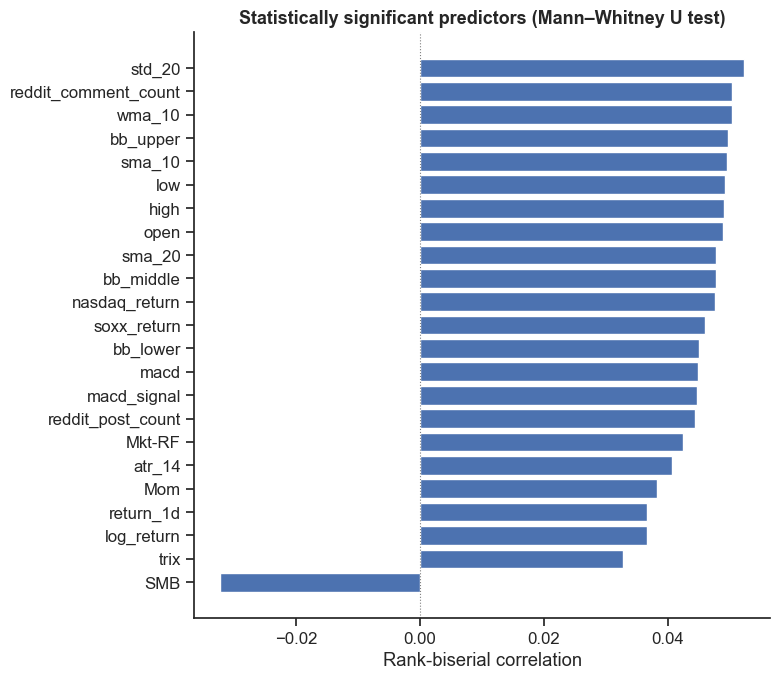

In [57]:
mw_sig = (
    mw_df[mw_df["p_value"] < 0.05]
    .sort_values("abs_rank_biserial", ascending=True)
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.barh(
    mw_sig["feature"],
    mw_sig["rank_biserial"],
    edgecolor="white"
)

ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Rank-biserial correlation")
ax.set_title(
    "Statistically significant predictors (Mann–Whitney U test)",
    fontsize=13,
    fontweight="bold"
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

*Only predictors with statistically significant Mann–Whitney U test results (p < 0.05) are visualized. Although these variables exhibit significant differences between classes, all effect sizes remain small (|RBC| < 0.06), indicating weak individual discriminatory power.*

**These results suggest that stock price direction cannot be reliably explained by any single predictor in isolation, supporting the use of multivariate machine learning models capable of combining information from multiple indicators.**

## 5. Multicollinearity analysis
Multicollinearity analysis was performed to identify and remove predictors
that carry highly redundant information. This step was primarily motivated
by the inclusion of Logistic Regression in the modeling pipeline, whose
coefficient estimates can become unstable and difficult to interpret when
highly correlated predictors are present.

Although XGBoost is inherently robust to multicollinearity due to its
tree-based structure, the same reduced feature set is applied to both
models. This decision was made to keep the comparison between models
consistent.

*Notably, `reddit_sentiment`, `news_sentiment`, `reddit_post_count`, `reddit_comment_count`,
`news_count` do not exhibit multicollinearity issues and are therefore
retained in full across both models.*

### 5.1 Variance Inflation Factor (VIF)
Variance Inflation Factor (VIF) analysis was conducted to identify multicollinearity among predictors. Following commonly adopted guidelines, variables with VIF values exceeding 10 were examined as potential sources of severe multicollinearity.

In [58]:
X_train_vif = X_train[numeric_cols].copy()

X_train_vif = X_train_vif.replace([np.inf, -np.inf], np.nan)
X_train_vif = X_train_vif.fillna(0)

def calculate_vif(X):
    vif_data = []

    for i, col in enumerate(X.columns):
        vif_data.append({
            "feature": col,
            "VIF": variance_inflation_factor(X.values, i)
        })

    return (
        pd.DataFrame(vif_data)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_df = calculate_vif(X_train_vif)


In [59]:
pd.options.display.float_format = '{:.0f}'.format
vif_df.sort_values("VIF", ascending=False)

,feature,VIF
0,sma_20,57007590219880
1,bb_lower,1902661439531
2,bb_middle,1802521363766
3,bb_upper,106547420121
4,std_20,18230687385
...,...,...
57,news_sentiment,1
58,month_cos,1
59,reddit_sentiment,1
60,dow_cos,1


Rather than removing all variables above the threshold automatically, predictors involved in deterministic or near-deterministic mathematical relationships were identified based on their definitions and removed iteratively. Examples include Bollinger Band components, yield curve variables, and alternative formulations of the same return measure.

| Group | Retained Feature(s) | Removed Feature(s) | Rationale |
|---------|---------|---------|---------|
| Yield Curve Indicators | `yield_spread` | `DGS10`, `DGS2` | The yield spread is calculated as the difference between the 10-year and 2-year Treasury yields. Retaining all three variables would introduce severe multicollinearity while providing little additional information. |
| Moving Average Indicators | `wma_10` | `sma_10`,`sma_20` | The weighted moving average was retained because it assigns greater importance to recent observations and therefore reacts more quickly to market changes. |
| Stochastic Oscillator Indicators | `stoch_k` | `stoch_d`, `williams_r` | Williams %R is mathematically related to the Stochastic Oscillator, while %D is a moving average of %K. Retaining only %K reduces redundancy while preserving the underlying momentum signal. |
| Return Indicators | `log_return` | `return_1d` | Both variables represent one-day price returns using different formulations. Log returns were retained because they are commonly used in financial time-series analysis and possess desirable statistical properties. |
| Volatility Indicators | `bb_lower` | `natr`, `bb_middle`, `std_20`, `bb_upper`, `atr_14`| NATR is a normalized version of ATR and captures information already represented by other retained volatility-related indicators. Bollinger Bands are constructed directly from the 20-day moving average and standard deviation. To reduce redundancy, only one representative volatility measure was retained. |
| MACD Indicators | `macd_signal` | `macd` | The MACD signal line is computed as an exponential moving average of the MACD series, resulting in a strong linear relationship between the two indicators. Only the signal line was retained. |
| Raw Price Variables | — | `open`, `high`, `low` | These variables exhibited very high multicollinearity and largely duplicate information already captured by technical indicators derived from price movements. |
| Market Benchmark Returns | `soxx_return` | `nasdaq_return` | Both variables represent broad market movements and were highly correlated. The SOXX semiconductor index was retained because it is more directly related to the semiconductor companies analyzed in this study. |
| Volume Indicators | `volume` | `log_volume` | Log volume is a logarithmic transformation of trading volume and therefore contains essentially the same information as the original variable. To avoid redundancy, only the original volume measure was retained. |
| Volatility Persistence Indicators | `rv_weekly` | `hv_lag_1`, `hv_lag_5`, `hv_lag_22`, `hist_vol_20`, `rv_monthly` | These variables represent alternative measures of historical volatility persistence and exhibited extremely high VIF values. |

In [60]:
features_to_drop = [
    "sma_20",
    "bb_middle",
    "std_20",
    "DGS10",
    "DGS2",
    "sma_10",
    "williams_r",
    "return_1d",
    "wma_10",
    "high",
    "low",
    "open",
    "macd",
    "stoch_d",
    "bb_upper",
    "nasdaq_return",
    "natr",
    'atr_14',
    "log_volume",
    "hv_lag_1",
    "hv_lag_5",
    "hv_lag_22",
    "rv_daily",
    "rv_monthly"
]

X_train_vif_reduced = X_train_vif.drop(columns=features_to_drop)

vif_df_reduced = calculate_vif(X_train_vif_reduced)

vif_df_reduced = (
    vif_df_reduced
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_df_reduced

,feature,VIF
0,FEDFUNDS,14
1,RF,11
2,yield_spread,6
3,soxx_return,5
4,roc_10,5
5,Mkt-RF,4
6,adosc,3
7,volume,3
8,log_return,3
9,macd_signal,3


*Following feature reduction, the maximum VIF values decreased substantially. Although FEDFUNDS and RF remained slightly above the commonly cited threshold of 10, these variables were retained because they represent distinct macroeconomic factors and do not constitute alternative formulations of the same information. Therefore, their inclusion was considered theoretically justified.*


In [61]:
# Final feature set after VIF analysis
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

print(f"X_train shape after VIF filtering: {X_train.shape}")
print(f"X_test shape after VIF filtering: {X_test.shape}")

X_train shape after VIF filtering: (5930, 39)
X_test shape after VIF filtering: (1483, 39)


In [62]:
X_train.columns

Index(['company', 'volume', 'rsi_14', 'macd_signal', 'stoch_k', 'roc_10',
       'mom_10', 'trix', 'bb_lower', 'hist_vol_20', 'obv', 'ad', 'adosc',
       'volume_chng', 'log_return', 'return_2d', 'return_5d', 'hl_ratio',
       'rv_weekly', 'FEDFUNDS', 'yield_spread', 'VIX', 'soxx_return', 'Mkt-RF',
       'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom', 'reddit_sentiment',
       'reddit_post_count', 'reddit_comment_count', 'news_sentiment',
       'news_count', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos'],
      dtype='object')

## 6. Preprocessing

Preprocessing steps differ between models based on their assumptions:

**Logistic Regression:**
 1. Sentiment/activity columns: NaN → 0 (no coverage = neutral/zero)
 2. One-hot encoding of `company` (drop_first=True to avoid multicollinearity)
 3. RobustScaler on all numeric columns — robust to outliers via median/IQR;
    outliers are retained as they carry meaningful market signal

**XGBoost:**
 1. Sentiment/activity columns: NaN → 0
 2. One-hot encoding of `company`
 
 *XGBoost is inherently robust to outliers and feature scale, so no scaling
 is applied. Remaining numeric columns are passed through as-is.*

In [63]:
categorical_cols = ['company']

sentiment_impute_cols = [c for c in SOCIAL_NEWS_COLS if c in X_train.columns]

numeric_remaining_cols = [
    c for c in X_train.columns
    if c not in categorical_cols and c not in sentiment_impute_cols
]

print("Categorical                 :", categorical_cols)
print("Reddit and News columns     :", sentiment_impute_cols)
print("Numeric                     :", numeric_remaining_cols)

Categorical                 : ['company']
Reddit and News columns     : ['reddit_sentiment', 'news_sentiment', 'reddit_post_count', 'reddit_comment_count', 'news_count']
Numeric                     : ['volume', 'rsi_14', 'macd_signal', 'stoch_k', 'roc_10', 'mom_10', 'trix', 'bb_lower', 'hist_vol_20', 'obv', 'ad', 'adosc', 'volume_chng', 'log_return', 'return_2d', 'return_5d', 'hl_ratio', 'rv_weekly', 'FEDFUNDS', 'yield_spread', 'VIX', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


### 6.1 Ablation study — feature configurations

 Four feature configurations are evaluated to isolate the contribution
 of sentiment and social media features:

 | Configuration | Description |
 |---|---|
 | `no_sentiment` | Technical + macro features only |
 | `reddit_only`  | Adds Reddit sentiment, post count, and comment count |
 | `news_only`    | Adds news sentiment and news count |
 | `both`         | Full feature set ( Reddit + news features included )|

In [64]:
REDDIT_COLS = ['reddit_sentiment', 'reddit_post_count', 'reddit_comment_count']
NEWS_COLS   = ['news_sentiment',   'news_count']

feature_configs = {
    'no_sentiment': [c for c in X_train.columns if c not in SOCIAL_NEWS_COLS],
    'reddit_only':  [c for c in X_train.columns if c not in NEWS_COLS],
    'news_only':    [c for c in X_train.columns if c not in REDDIT_COLS],
    'both':         list(X_train.columns),
}

for name, cols in feature_configs.items():
    print(f"{name:15s}: {len(cols):2d} features")


no_sentiment   : 34 features
reddit_only    : 37 features
news_only      : 36 features
both           : 39 features


### 6.2 Preprocessor factory
A helper function returns a fresh, unfitted preprocessor for a given
feature configuration and model type. Calling it separately for each
configuration ensures that every pipeline is fit independently on the
training set, with no leakage between configurations.

Transformer logic per column group:

 | Column group              | Logistic Regression            | XGBoost          |
 |---------------------------|--------------------------------|------------------|
 | Sentiment / activity      | Impute (0) → RobustScaler      | Impute (0)       |
 | Remaining numeric         | RobustScaler                   | passthrough      |
 | company (categorical)     | OneHotEncoder (drop_first=True) | OneHotEncoder (drop_first=True) |


In [69]:
def build_preprocessor(feature_cols: list[str], model_type: str) -> ColumnTransformer:
    sent_cols = [c for c in sentiment_impute_cols if c in feature_cols]
    num_cols  = [c for c in numeric_remaining_cols if c in feature_cols]
    cat_cols  = [c for c in categorical_cols if c in feature_cols]

    if model_type == 'lr':
        sent_pipe = Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value=0)),
            ('scale',  RobustScaler())
        ])

        num_pipe = Pipeline([
            ('scale',  RobustScaler())
        ])

    else:  # xgb
        sent_pipe = SimpleImputer(strategy='constant', fill_value=0)
        num_pipe = 'passthrough'
    transformers = []

    if sent_cols:
        transformers.append(('sentiment', sent_pipe, sent_cols))

    if num_cols:
        transformers.append(('numeric', num_pipe, num_cols))

    if cat_cols:
        transformers.append((
            'cat',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            cat_cols
        ))

    return ColumnTransformer(transformers=transformers, remainder='drop')

## 7. Logistic regression

Logistic Regression serves as an interpretable baseline model.

A separate pipeline is trained for each of the four ablation configurations.
Each pipeline consists of:
 1. A fresh preprocessor (built via `build_preprocessor`)
 2. Logistic Regression with L2 regularization

Hyperparameter tuning is performed via GridSearchCV with TimeSeriesSplit
to respect the temporal structure of the data.

### 7.1 Hyperparameter tuning and prediction

In [66]:
param_grid_lr = {
    'model__C':        [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver':   ['lbfgs'],
    'model__max_iter': [1000],
}

tscv = TimeSeriesSplit(n_splits=5)

lr_results    = {}   # metrics per configuration
lr_pipelines  = {}   # fitted pipelines per configuration
lr_best_params = {}  # best hyperparameters per configuration

for config_name, feature_cols in feature_configs.items():
    print(f"\n{'─'*55}")
    print(f"  Configuration: {config_name}  ({len(feature_cols)} features)")
    print(f"{'─'*55}")

    pipeline = Pipeline([
        ('prep',  build_preprocessor(feature_cols, model_type='lr')),
        ('model', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_lr,
        cv=tscv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train[feature_cols], y_train)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_

    y_pred      = best_pipeline.predict(X_test[feature_cols])
    y_pred_prob = best_pipeline.predict_proba(X_test[feature_cols])[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_pred_prob),
        'f1':        f1_score(y_test, y_pred),
        'f1_macro':  f1_score(y_test, y_pred, average='macro'),
    }

    lr_results[config_name]     = metrics
    lr_pipelines[config_name]   = best_pipeline
    lr_best_params[config_name] = best_params

    print(f"  Best params : {best_params}")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
    print(f"  F1          : {metrics['f1']:.4f}")
    print(f"  F1 (macro)  : {metrics['f1_macro']:.4f}")




───────────────────────────────────────────────────────
  Configuration: no_sentiment  (34 features)
───────────────────────────────────────────────────────
  Best params : {'model__C': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
  Accuracy    : 0.5152
  ROC-AUC     : 0.5263
  F1          : 0.4717
  F1 (macro)  : 0.5119

───────────────────────────────────────────────────────
  Configuration: reddit_only  (37 features)
───────────────────────────────────────────────────────
  Best params : {'model__C': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
  Accuracy    : 0.5253
  ROC-AUC     : 0.5288
  F1          : 0.4601
  F1 (macro)  : 0.5183

───────────────────────────────────────────────────────
  Configuration: news_only  (36 features)
───────────────────────────────────────────────────────
  Best params : {'model__C': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
  Accuracy    : 0.5165
  ROC-AUC     : 0.5281
  F1          : 0.4801
  F1 (macro)  : 

### 7.2 Results comparison across configurations

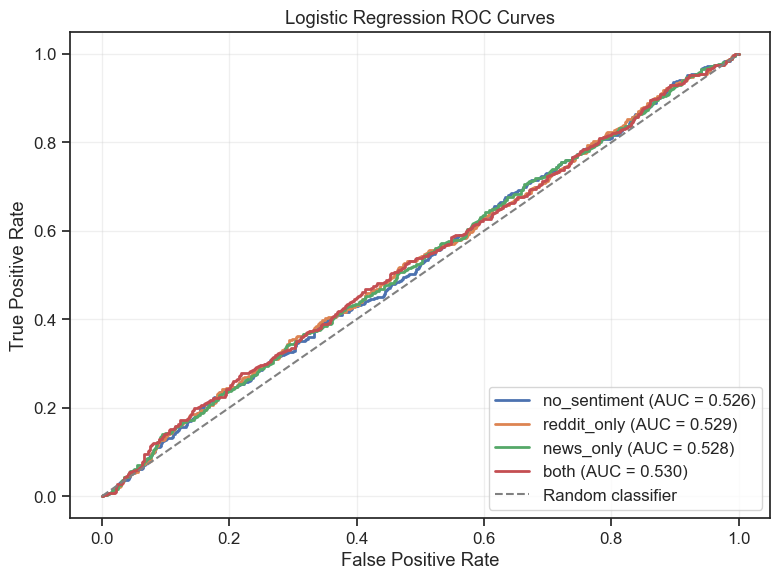

In [67]:
config_order = ['no_sentiment', 'reddit_only', 'news_only', 'both']

plt.figure(figsize=(8,6))

for config in config_order:

    model = lr_pipelines[config]

    y_prob = model.predict_proba(
        X_test[feature_configs[config]]
    )[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{config} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    label='Random classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

*Logistic Regression achieved ROC-AUC values between 0.526 and 0.530 across all feature configurations. The results are only marginally above random guessing (ROC-AUC = 0.50), indicating that the relationship between the available predictors and next-day stock price direction is either weak, highly non-linear, or obscured by market noise. The inclusion of Reddit and news features produced only minor improvements in predictive performance.*

## 8. XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble method based on 
gradient-boosted decision trees. Unlike Logistic Regression, it captures 
non-linear relationships and feature interactions, making it particularly 
well-suited for financial time-series prediction where the relationship 
between predictors and the target is rarely linear.

*A separate pipeline is trained for each of the four ablation configurations, 
following the same structure as the Logistic Regression pipeline. 
Hyperparameter tuning is performed via GridSearchCV with TimeSeriesSplit.*

### 8.1 Hyperparameter tuning and predicition

In [70]:
param_grid_xgb = {
    'model__n_estimators':  [100, 300, 500],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.7,0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5],
}

xgb_results     = {}
xgb_pipelines   = {}
xgb_best_params = {}

for config_name, feature_cols in feature_configs.items():
    print(f"\n{'─'*55}")
    print(f"  Configuration: {config_name}  ({len(feature_cols)} features)")
    print(f"{'─'*55}")

    pipeline = Pipeline([
        ('prep',  build_preprocessor(feature_cols, model_type='xgb')),
        ('model', XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        ))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train[feature_cols], y_train)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_

    y_pred      = best_pipeline.predict(X_test[feature_cols])
    y_pred_prob = best_pipeline.predict_proba(X_test[feature_cols])[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_pred_prob),
        'f1':        f1_score(y_test, y_pred),
        'f1_macro':  f1_score(y_test, y_pred, average='macro'),
    }

    xgb_results[config_name]     = metrics
    xgb_pipelines[config_name]   = best_pipeline
    xgb_best_params[config_name] = best_params

    print(f"  Best params : {best_params}")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
    print(f"  F1          : {metrics['f1']:.4f}")
    print(f"  F1 (macro)  : {metrics['f1_macro']:.4f}")


───────────────────────────────────────────────────────
  Configuration: no_sentiment  (34 features)
───────────────────────────────────────────────────────
  Best params : {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}
  Accuracy    : 0.5199
  ROC-AUC     : 0.5079
  F1          : 0.5860
  F1 (macro)  : 0.5073

───────────────────────────────────────────────────────
  Configuration: reddit_only  (37 features)
───────────────────────────────────────────────────────
  Best params : {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 100, 'model__subsample': 0.7}
  Accuracy    : 0.5408
  ROC-AUC     : 0.5382
  F1          : 0.5910
  F1 (macro)  : 0.5338

───────────────────────────────────────────────────────
  Configuration: news_only  (36 features)
────────────────────────────────

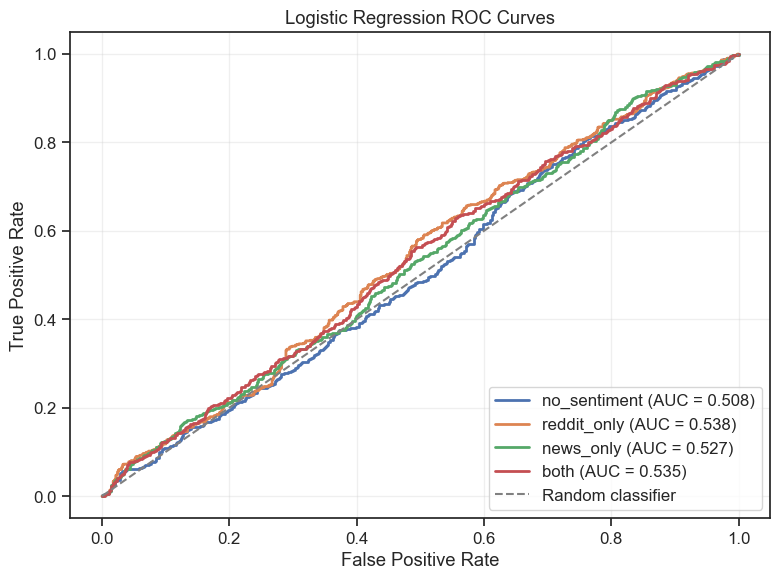

In [71]:
config_order = ['no_sentiment', 'reddit_only', 'news_only', 'both']

plt.figure(figsize=(8,6))

for config in config_order:

    model = xgb_pipelines[config]

    y_prob = model.predict_proba(
        X_test[feature_configs[config]]
    )[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{config} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    label='Random classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2. Results comparison across configurations

XGBoost achieved ROC-AUC values between 0.508 and 0.538 across all 
feature configurations — marginally above random guessing (ROC-AUC = 0.50), 
consistent with the results obtained by Logistic Regression.

The `reddit_only` configuration produced the highest ROC-AUC (0.538) and 
F1 macro (0.534), suggesting that Reddit-derived features carry a slightly 
stronger signal than news features for next-day direction prediction. 
However, the differences across configurations remain small and are unlikely 
to be statistically significant.

Notably, the optimal hyperparameters across all configurations converged 
toward shallow trees (`max_depth=3`) and strong regularization 
(`min_child_weight=3–5`, `subsample=0.7–0.8`), which is consistent with 
a low signal-to-noise ratio in the data. The model complexity was 
effectively constrained by the cross-validation procedure, indicating 
that the weak predictive performance is not attributable to underfitting 
but rather to the limited predictability of next-day price direction 
from the available features.

## 9. Conclusion

These results are consistent with the Efficient Market Hypothesis (EMH), 
which posits that asset prices already reflect all publicly available 
information, making systematic short-term prediction from public news 
and social media data inherently difficult. The findings align with 
prior literature (e.g., Tetlock, 2007; Barber & Odean, 2008) which 
documents that while sentiment and attention measures carry statistically 
detectable signals, their economic magnitude is typically small.